# AMI Subset Dataset Analysis

This notebook inspects the pilot AMI subset audio and gold transcripts, matches sessions, computes descriptive statistics, and saves CSV summaries and publication-friendly charts.

Notes:
- No randomness is used anywhere so results are fully reproducible.
- Edit the paths in the configuration cell if your folder layout differs.

In [1]:
from __future__ import annotations

import re
import wave
from pathlib import Path
from typing import Iterable, Optional

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Paths (edit here if your folder structure differs) ----
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_AUDIO_DIR = PROJECT_ROOT / 'data' / 'raw_audio'
GOLD_TRANSCRIPTS_DIR = PROJECT_ROOT / 'data' / 'gold_transcripts'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Output files ----
SESSION_SUMMARY_CSV = OUTPUT_DIR / 'ami_subset_session_summary.csv'
AUDIO_FILE_CSV = OUTPUT_DIR / 'ami_subset_audio_file_stats.csv'
TRANSCRIPT_FILE_CSV = OUTPUT_DIR / 'ami_subset_transcript_file_stats.csv'
OVERVIEW_STATS_CSV = OUTPUT_DIR / 'ami_subset_overview_stats.csv'

CHART_AUDIO_DURATION = OUTPUT_DIR / 'session_audio_duration_minutes.png'
CHART_TRANSCRIPT_WORDS = OUTPUT_DIR / 'session_transcript_word_counts.png'
CHART_COMPLETENESS = OUTPUT_DIR / 'session_completeness_matrix.png'

# ---- Configuration ----
AUDIO_EXTS = {'.wav'}
SESSION_PATTERN = re.compile(r'^(?P<session>[A-Z]{2}\d{4}[a-d])')
TRANSCRIPT_PATTERN = re.compile(r'^(?P<session>[A-Z]{2}\d{4}[a-d])\.(?P<speaker>[A-D])\.words\.xml$')

# ---- Plot style ----
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
def iter_files(root: Path, exts: Optional[set[str]] = None) -> Iterable[Path]:
    if not root.exists():
        return []
    for path in sorted(root.rglob('*')):
        if path.is_file() and (exts is None or path.suffix.lower() in exts):
            yield path


def parse_session_id_from_name(name: str) -> Optional[str]:
    match = SESSION_PATTERN.match(name)
    return match.group('session') if match else None


def parse_transcript_name(name: str) -> tuple[Optional[str], Optional[str], bool]:
    match = TRANSCRIPT_PATTERN.match(name)
    if not match:
        return parse_session_id_from_name(name), None, True
    return match.group('session'), match.group('speaker'), False


def get_wav_duration_seconds(path: Path) -> Optional[float]:
    try:
        with wave.open(str(path), 'rb') as wf:
            frames = wf.getnframes()
            rate = wf.getframerate()
            if rate <= 0:
                return None
            return frames / float(rate)
    except wave.Error:
        return None


def _safe_float(value: str) -> Optional[float]:
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def extract_word_stats_from_words_xml(path: Path) -> dict:
    import xml.etree.ElementTree as ET

    word_count = 0
    start_times: list[float] = []
    end_times: list[float] = []

    try:
        tree = ET.parse(path)
        root = tree.getroot()
    except ET.ParseError:
        return {
            'word_count': 0,
            'start_time_min': None,
            'end_time_max': None,
            'parse_error': True,
        }

    for elem in root.iter():
        tag = elem.tag.split('}')[-1].lower()
        if tag in {'w', 'word'}:
            text = (elem.text or '').strip()
            if text:
                word_count += 1

        for key in ('starttime', 'start', 'stime'):
            if key in elem.attrib:
                value = _safe_float(elem.attrib.get(key))
                if value is not None:
                    start_times.append(value)
        for key in ('endtime', 'end', 'etime'):
            if key in elem.attrib:
                value = _safe_float(elem.attrib.get(key))
                if value is not None:
                    end_times.append(value)

    start_time_min = min(start_times) if start_times else None
    end_time_max = max(end_times) if end_times else None

    return {
        'word_count': word_count,
        'start_time_min': start_time_min,
        'end_time_max': end_time_max,
        'parse_error': False,
    }

In [3]:
# ---- Collect audio files ----
audio_rows = []
audio_missing_duration = []

if not RAW_AUDIO_DIR.exists():
    print(f'Warning: audio folder not found: {RAW_AUDIO_DIR}')

for path in iter_files(RAW_AUDIO_DIR):
    session_id = parse_session_id_from_name(path.name)
    ext = path.suffix.lower()
    duration_seconds = None
    if ext in AUDIO_EXTS:
        duration_seconds = get_wav_duration_seconds(path)
        if duration_seconds is None:
            audio_missing_duration.append(path)

    audio_rows.append({
        'session_id': session_id,
        'audio_file': str(path),
        'extension': ext,
        'duration_seconds': duration_seconds,
        'duration_missing': duration_seconds is None and ext in AUDIO_EXTS,
        'is_supported_audio': ext in AUDIO_EXTS,
    })

audio_df = pd.DataFrame(audio_rows)
if audio_df.empty:
    audio_df = pd.DataFrame(columns=[
        'session_id',
        'audio_file',
        'extension',
        'duration_seconds',
        'duration_missing',
        'is_supported_audio',
    ])

audio_df.to_csv(AUDIO_FILE_CSV, index=False)
audio_df.head()

,session_id,audio_file,extension,duration_seconds,duration_missing,is_supported_audio
0,NaN,/Users/adityagoyal/SRH/Thesis Research/thesis_...,,NaN,False,False
1,ES2014a,/Users/adityagoyal/SRH/Thesis Research/thesis_...,.wav,1149.013375,False,True
2,ES2014b,/Users/adityagoyal/SRH/Thesis Research/thesis_...,.wav,2319.893375,False,True
3,ES2014c,/Users/adityagoyal/SRH/Thesis Research/thesis_...,.wav,2273.525375,False,True
4,ES2014d,/Users/adityagoyal/SRH/Thesis Research/thesis_...,.wav,2911.360000,False,True


In [4]:
# ---- Collect transcript files ----
transcript_rows = []
parse_errors = []

if not GOLD_TRANSCRIPTS_DIR.exists():
    print(f'Warning: transcript folder not found: {GOLD_TRANSCRIPTS_DIR}')

for path in iter_files(GOLD_TRANSCRIPTS_DIR, exts={'.xml'}):
    session_id, speaker_id, name_mismatch = parse_transcript_name(path.name)
    stats = extract_word_stats_from_words_xml(path)
    if stats['parse_error']:
        parse_errors.append(path)

    transcript_rows.append({
        'session_id': session_id,
        'speaker_id': speaker_id,
        'transcript_file': str(path),
        'name_mismatch': name_mismatch,
        'word_count': stats['word_count'],
        'start_time_min': stats['start_time_min'],
        'end_time_max': stats['end_time_max'],
        'parse_error': stats['parse_error'],
    })

transcript_df = pd.DataFrame(transcript_rows)
if transcript_df.empty:
    transcript_df = pd.DataFrame(columns=[
        'session_id',
        'speaker_id',
        'transcript_file',
        'name_mismatch',
        'word_count',
        'start_time_min',
        'end_time_max',
        'parse_error',
    ])

transcript_df['transcript_duration_seconds'] = (
    transcript_df['end_time_max'] - transcript_df['start_time_min']
)
transcript_df.to_csv(TRANSCRIPT_FILE_CSV, index=False)
transcript_df.head()

,session_id,speaker_id,transcript_file,name_mismatch,word_count,start_time_min,end_time_max,parse_error,transcript_duration_seconds
0,ES2014a,A,/Users/adityagoyal/SRH/Thesis Research/thesis_...,False,1411,71.42,1148.92,False,1077.50
1,ES2014a,B,/Users/adityagoyal/SRH/Thesis Research/thesis_...,False,330,91.88,1143.32,False,1051.44
2,ES2014a,C,/Users/adityagoyal/SRH/Thesis Research/thesis_...,False,289,107.64,1143.34,False,1035.70
3,ES2014a,D,/Users/adityagoyal/SRH/Thesis Research/thesis_...,False,492,76.13,1144.83,False,1068.70
4,ES2014b,A,/Users/adityagoyal/SRH/Thesis Research/thesis_...,False,2354,57.32,2317.31,False,2259.99


In [5]:
# ---- Build per-session summary ----
session_ids = sorted({
    sid for sid in audio_df['session_id'].dropna().tolist()
} | {
    sid for sid in transcript_df['session_id'].dropna().tolist()
})

summary_rows = []
for session_id in session_ids:
    audio_session = audio_df[audio_df['session_id'] == session_id]
    transcript_session = transcript_df[transcript_df['session_id'] == session_id]

    audio_duration_seconds = audio_session['duration_seconds'].dropna().sum()
    transcript_word_count = transcript_session['word_count'].dropna().sum()

    speakers = sorted({
        s for s in transcript_session['speaker_id'].dropna().tolist()
    })

    start_time_min = transcript_session['start_time_min'].dropna().min()
    end_time_max = transcript_session['end_time_max'].dropna().max()
    transcript_duration_seconds = None
    if pd.notna(start_time_min) and pd.notna(end_time_max):
        transcript_duration_seconds = float(end_time_max - start_time_min)

    summary_rows.append({
        'session_id': session_id,
        'audio_file_count': int(len(audio_session)),
        'transcript_file_count': int(len(transcript_session)),
        'has_audio': len(audio_session) > 0,
        'has_transcript': len(transcript_session) > 0,
        'audio_duration_seconds': float(audio_duration_seconds) if len(audio_session) > 0 else None,
        'transcript_word_count': int(transcript_word_count) if len(transcript_session) > 0 else None,
        'transcript_duration_seconds': transcript_duration_seconds,
        'speakers_present': ','.join(speakers) if speakers else None,
        'name_mismatch_count': int(transcript_session['name_mismatch'].sum()),
        'transcript_parse_error_count': int(transcript_session['parse_error'].sum()),
        'audio_duration_missing_count': int(audio_session['duration_missing'].sum()),
    })

session_summary_df = pd.DataFrame(summary_rows)
session_summary_df.to_csv(SESSION_SUMMARY_CSV, index=False)
session_summary_df

,session_id,audio_file_count,transcript_file_count,has_audio,has_transcript,audio_duration_seconds,transcript_word_count,transcript_duration_seconds,speakers_present,name_mismatch_count,transcript_parse_error_count,audio_duration_missing_count
0,ES2014a,1,4,True,True,1149.013375,2522,1077.500,"A,B,C,D",0,0,0
1,ES2014b,1,4,True,True,2319.893375,6935,2260.070,"A,B,C,D",0,0,0
2,ES2014c,1,4,True,True,2273.525375,7330,2182.160,"A,B,C,D",0,0,0
3,ES2014d,1,4,True,True,2911.360000,9058,2911.300,"A,B,C,D",0,0,0
4,ES2015a,1,4,True,True,1146.560000,2945,1078.945,"A,B,C,D",0,0,0
5,ES2015b,1,4,True,True,2294.858688,8120,2266.656,"A,B,C,D",0,0,0
6,ES2015c,1,4,True,True,2135.893375,7166,2096.680,"A,B,C,D",0,0,0
7,ES2015d,1,4,True,True,1931.562688,6838,1872.220,"A,B,C,D",0,0,0
8,ES2016a,1,4,True,True,1384.189375,3420,1370.770,"A,B,C,D",0,0,0
9,ES2016b,1,4,True,True,2412.224000,5663,2390.679,"A,B,C,D",0,0,0


In [6]:
# ---- Overview statistics ----
def _describe_series(series: pd.Series) -> dict:
    values = series.dropna()
    if values.empty:
        return {
            'count': 0,
            'min': None,
            'mean': None,
            'median': None,
            'max': None,
        }
    return {
        'count': int(values.count()),
        'min': float(values.min()),
        'mean': float(values.mean()),
        'median': float(values.median()),
        'max': float(values.max()),
    }

overview = []
overview.append({'metric': 'session_count', 'value': int(len(session_summary_df))})
overview.append({'metric': 'audio_file_count', 'value': int(len(audio_df))})
overview.append({'metric': 'transcript_file_count', 'value': int(len(transcript_df))})

audio_durations = _describe_series(session_summary_df['audio_duration_seconds'])
for key, value in audio_durations.items():
    overview.append({'metric': f'audio_duration_seconds_{key}', 'value': value})

word_counts = _describe_series(session_summary_df['transcript_word_count'])
for key, value in word_counts.items():
    overview.append({'metric': f'transcript_word_count_{key}', 'value': value})

transcript_durations = _describe_series(session_summary_df['transcript_duration_seconds'])
for key, value in transcript_durations.items():
    overview.append({'metric': f'transcript_duration_seconds_{key}', 'value': value})

missing_audio_sessions = session_summary_df[~session_summary_df['has_audio']]['session_id'].tolist()
missing_transcript_sessions = session_summary_df[~session_summary_df['has_transcript']]['session_id'].tolist()

overview.append({
    'metric': 'missing_audio_sessions',
    'value': ','.join(missing_audio_sessions) if missing_audio_sessions else None,
})
overview.append({
    'metric': 'missing_transcript_sessions',
    'value': ','.join(missing_transcript_sessions) if missing_transcript_sessions else None,
})

overview_df = pd.DataFrame(overview)
overview_df.to_csv(OVERVIEW_STATS_CSV, index=False)
overview_df

,metric,value
0,session_count,36.000000
1,audio_file_count,37.000000
2,transcript_file_count,144.000000
3,audio_duration_seconds_count,36.000000
4,audio_duration_seconds_min,838.833313
5,audio_duration_seconds_mean,1836.056443
6,audio_duration_seconds_median,1986.778000
7,audio_duration_seconds_max,2911.360000
8,transcript_word_count_count,36.000000
9,transcript_word_count_min,1358.000000


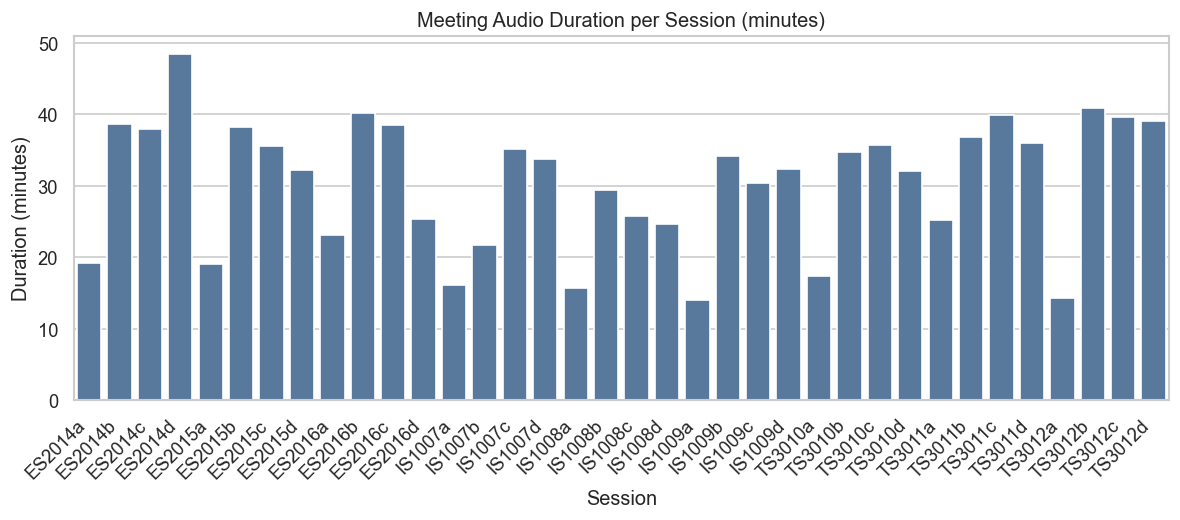

In [7]:
# ---- Chart: audio duration per session ----
if not session_summary_df.empty:
    plot_df = session_summary_df.copy()
    plot_df['audio_duration_minutes'] = plot_df['audio_duration_seconds'] / 60.0

    plt.figure(figsize=(10, 4.5))
    ax = sns.barplot(
        data=plot_df,
        x='session_id',
        y='audio_duration_minutes',
        color='#4C78A8',
    )
    ax.set_title('Meeting Audio Duration per Session (minutes)')
    ax.set_xlabel('Session')
    ax.set_ylabel('Duration (minutes)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(CHART_AUDIO_DURATION)
    plt.show()

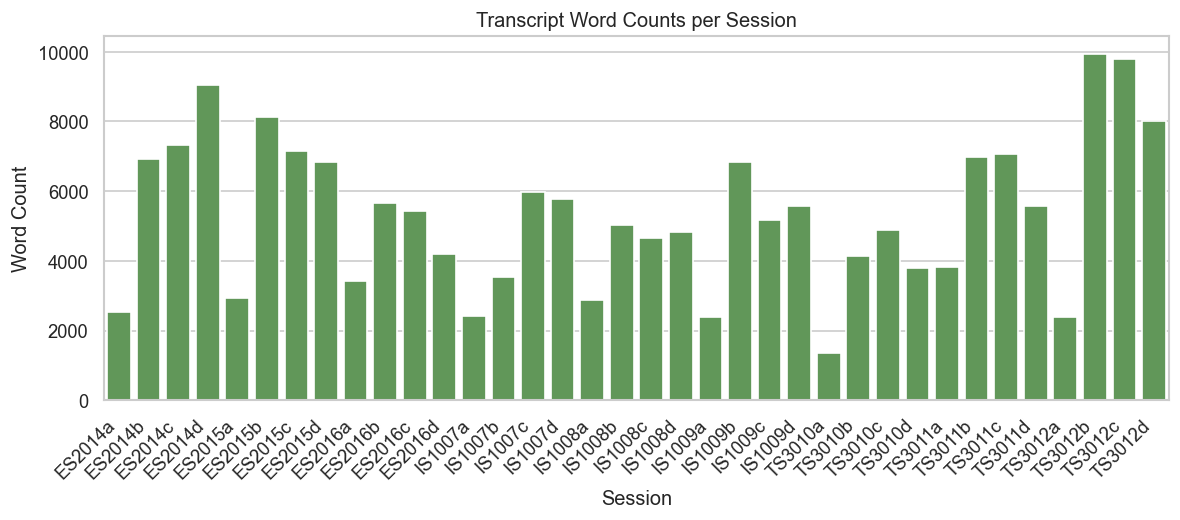

In [8]:
# ---- Chart: transcript word counts per session ----
if not session_summary_df.empty:
    plot_df = session_summary_df.copy()

    plt.figure(figsize=(10, 4.5))
    ax = sns.barplot(
        data=plot_df,
        x='session_id',
        y='transcript_word_count',
        color='#59A14F',
    )
    ax.set_title('Transcript Word Counts per Session')
    ax.set_xlabel('Session')
    ax.set_ylabel('Word Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(CHART_TRANSCRIPT_WORDS)
    plt.show()

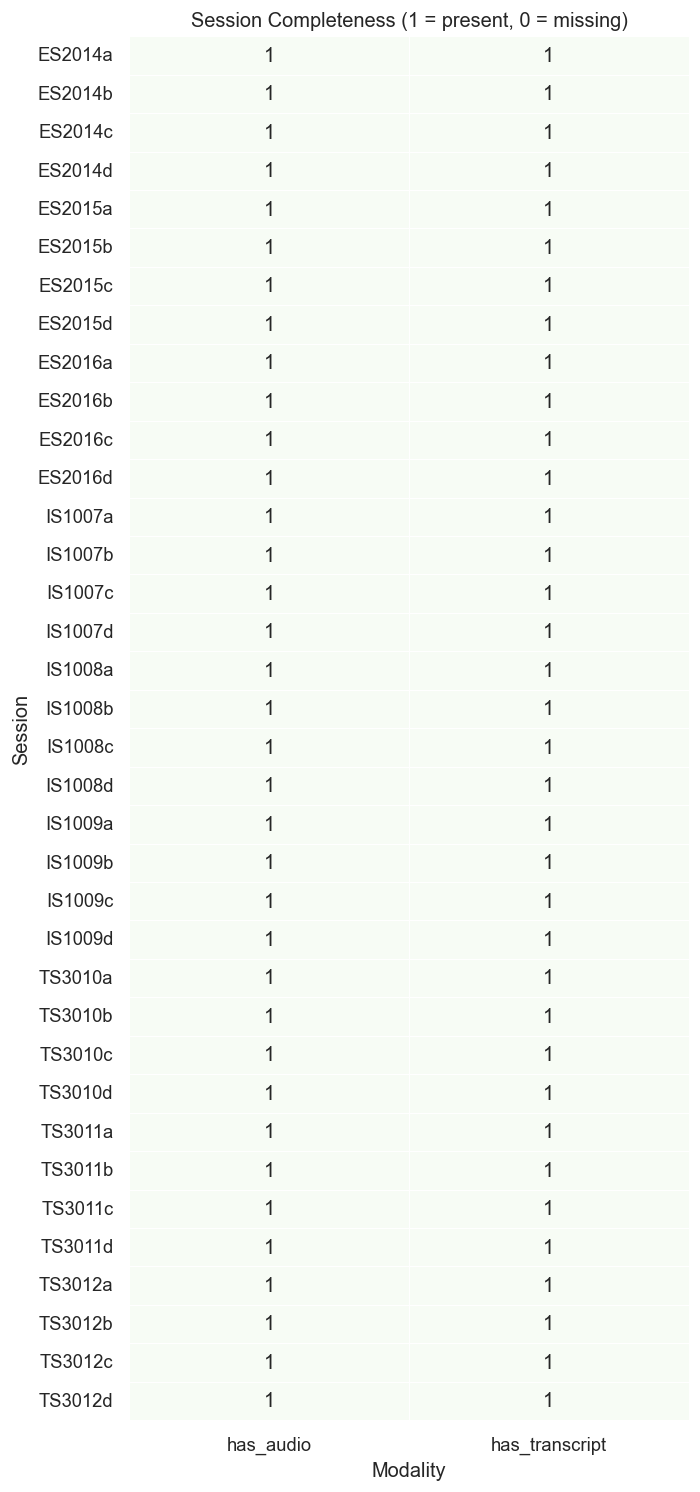

In [9]:
# ---- Chart: completeness matrix ----
if not session_summary_df.empty:
    completeness_df = session_summary_df.set_index('session_id')[['has_audio', 'has_transcript']]
    completeness_numeric = completeness_df.astype(int)

    plt.figure(figsize=(6, max(2.5, 0.35 * len(completeness_numeric))))
    ax = sns.heatmap(
        completeness_numeric,
        cmap='Greens',
        cbar=False,
        linewidths=0.5,
        linecolor='white',
        annot=True,
        fmt='d',
    )
    ax.set_title('Session Completeness (1 = present, 0 = missing)')
    ax.set_xlabel('Modality')
    ax.set_ylabel('Session')
    plt.tight_layout()
    plt.savefig(CHART_COMPLETENESS)
    plt.show()

## Outputs
The following files are written to the output folder:
- ami_subset_session_summary.csv
- ami_subset_audio_file_stats.csv
- ami_subset_transcript_file_stats.csv
- ami_subset_overview_stats.csv
- session_audio_duration_minutes.png
- session_transcript_word_counts.png
- session_completeness_matrix.png